<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/07_Global_MultiAsset_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 07 — Global Multi-Asset Models: BTC, ETH, SOL and XRP

This notebook trains pooled **MLP, GRU and LSTM** models across all four assets using the best BTC-validation lookback selected for each architecture:

- **MLP:** 30 days
- **GRU:** 7 days
- **LSTM:** 14 days

The underlying modelling design is unchanged:
- Each sequence belongs to one asset only.
- Chronological train/validation/test splits are preserved.
- Feature and target scalers are fitted per asset using training data only.
- Asset identity is supplied through one-hot encoding.
- Validation metrics are reported separately for BTC, ETH, SOL and XRP.
- The untouched test set is prepared but not evaluated here.


## 1. Imports and reproducibility


In [1]:
from google.colab import drive
from pathlib import Path
import json, random, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, GRU, LSTM, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass
print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0


## 2. Paths and configuration


In [2]:
drive.mount('/content/drive')

shared_project_dir = Path('/content/drive/MyDrive/Quant Research')
daily_feature_path = (
    shared_project_dir
    / 'data'
    / 'model_ready'
    / 'crypto_daily_features_v1.parquet'
)

results_root = (
    shared_project_dir
    / 'results'
    / 'GLOBAL_4_ASSETS'
)

models_root = (
    shared_project_dir
    / 'models'
    / 'GLOBAL_4_ASSETS'
)

artifacts_root = (
    shared_project_dir
    / 'data'
    / 'model_ready'
    / 'GLOBAL_4_ASSETS'
)

for d in [results_root, models_root, artifacts_root]:
    d.mkdir(parents=True, exist_ok=True)

ASSETS = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT']

# Best BTC-validation lookback already selected for each architecture.
MODEL_LOOKBACKS = {
    'MLP': 30,
    'GRU': 7,
    'LSTM': 14,
}

LOOKBACK_OPTIONS = sorted(set(MODEL_LOOKBACKS.values()))

FEATURE_COLUMNS = [
    'log_realized_variance',
    'daily_return',
    'absolute_daily_return',
    'high_low_range',
    'log_volume',
    'rv_mean_7d',
    'rv_mean_30d',
]

TARGET_COLUMN = 'target_log_rv'

print('Daily feature file:', daily_feature_path)
print('Model lookbacks:', MODEL_LOOKBACKS)


Mounted at /content/drive
Daily feature file: /content/drive/MyDrive/Quant Research/data/model_ready/crypto_daily_features_v1.parquet
Model lookbacks: {'MLP': 30, 'GRU': 7, 'LSTM': 14}


## 3. Load and validate daily features


In [3]:
daily_df = pd.read_parquet(daily_feature_path)
daily_df = (daily_df.loc[daily_df['symbol'].isin(ASSETS)]
            .sort_values(['symbol','date']).reset_index(drop=True))
required = {'symbol','date','target_date','target_log_rv','target_rv','split',*FEATURE_COLUMNS}
missing = required - set(daily_df.columns)
if missing:
    raise ValueError(f'Missing columns: {missing}')
print('Daily feature shape:', daily_df.shape)
display(daily_df.groupby('symbol').agg(first_date=('date','min'), last_date=('date','max'), daily_rows=('date','size')))


Daily feature shape: (11738, 27)


,first_date,last_date,daily_rows
symbol,,,
BTCUSDT,2017-08-17 00:00:00+00:00,2026-08-01 00:00:00+00:00,3272
ETHUSDT,2017-08-17 00:00:00+00:00,2026-08-01 00:00:00+00:00,3272
SOLUSDT,2020-08-11 00:00:00+00:00,2026-08-01 00:00:00+00:00,2182
XRPUSDT,2018-05-04 00:00:00+00:00,2026-08-01 00:00:00+00:00,3012


## 4. Create asset-specific sequences for the required lookbacks


In [4]:
def create_asset_sequences(asset_df, feature_columns, lookback_days):
    asset_df = asset_df.sort_values('date').reset_index(drop=True)

    X_values = []
    y_values = []
    metadata_rows = []

    for end_index in range(lookback_days - 1, len(asset_df)):
        start_index = end_index - lookback_days + 1

        window = asset_df.iloc[start_index:end_index + 1]
        final_row = asset_df.iloc[end_index]

        dates = window['date']

        expected = pd.date_range(
            start=dates.iloc[0],
            periods=lookback_days,
            freq='D',
            tz=dates.iloc[0].tz,
        )

        # Require a truly consecutive daily sequence.
        if not np.array_equal(
            dates.to_numpy(),
            expected.to_numpy(),
        ):
            continue

        if window[feature_columns].isna().any().any():
            continue

        if pd.isna(final_row[TARGET_COLUMN]):
            continue

        if (
            final_row['target_date']
            - final_row['date']
            != pd.Timedelta(days=1)
        ):
            continue

        if final_row['split'] not in {
            'train',
            'validation',
            'test',
        }:
            continue

        X_values.append(
            window[feature_columns]
            .to_numpy(dtype=np.float32)
        )

        y_values.append(
            np.float32(
                final_row[TARGET_COLUMN]
            )
        )

        metadata_rows.append({
            'symbol': final_row['symbol'],
            'sequence_start_date': dates.iloc[0],
            'sequence_end_date': final_row['date'],
            'target_date': final_row['target_date'],
            'actual_log_rv': final_row['target_log_rv'],
            'actual_rv': final_row['target_rv'],
            'split': final_row['split'],
        })

    return (
        np.asarray(
            X_values,
            dtype=np.float32,
        ),
        np.asarray(
            y_values,
            dtype=np.float32,
        ),
        pd.DataFrame(
            metadata_rows
        ),
    )


datasets_by_lookback = {}

for lookback_days in LOOKBACK_OPTIONS:

    print(
        f"\n{'=' * 60}\n"
        f"LOOKBACK = {lookback_days} DAYS\n"
        f"{'=' * 60}"
    )

    asset_datasets = {}

    for symbol in ASSETS:

        X_asset, y_asset, meta_asset = (
            create_asset_sequences(
                daily_df.loc[
                    daily_df['symbol'].eq(symbol)
                ].copy(),
                FEATURE_COLUMNS,
                lookback_days,
            )
        )

        if meta_asset.empty:
            raise ValueError(
                f'No valid sequences created for '
                f'{symbol}, lookback={lookback_days}'
            )

        asset_datasets[symbol] = {
            'X_raw': X_asset,
            'y_raw': y_asset,
            'metadata': meta_asset,
        }

        print(
            symbol,
            X_asset.shape,
            meta_asset['split']
            .value_counts()
            .to_dict(),
        )

    datasets_by_lookback[
        lookback_days
    ] = asset_datasets



LOOKBACK = 7 DAYS
BTCUSDT (3234, 7, 7) {'train': 2504, 'validation': 365, 'test': 365}
ETHUSDT (3234, 7, 7) {'train': 2504, 'validation': 365, 'test': 365}
SOLUSDT (2144, 7, 7) {'train': 1414, 'validation': 365, 'test': 365}
XRPUSDT (2974, 7, 7) {'train': 2244, 'validation': 365, 'test': 365}

LOOKBACK = 14 DAYS
BTCUSDT (3227, 14, 7) {'train': 2497, 'validation': 365, 'test': 365}
ETHUSDT (3227, 14, 7) {'train': 2497, 'validation': 365, 'test': 365}
SOLUSDT (2137, 14, 7) {'train': 1407, 'validation': 365, 'test': 365}
XRPUSDT (2967, 14, 7) {'train': 2237, 'validation': 365, 'test': 365}

LOOKBACK = 30 DAYS
BTCUSDT (3211, 30, 7) {'train': 2481, 'validation': 365, 'test': 365}
ETHUSDT (3211, 30, 7) {'train': 2481, 'validation': 365, 'test': 365}
SOLUSDT (2121, 30, 7) {'train': 1391, 'validation': 365, 'test': 365}
XRPUSDT (2951, 30, 7) {'train': 2221, 'validation': 365, 'test': 365}


## 5. Per-asset scaling and pooled arrays for each required lookback


In [5]:
def build_pooled_dataset(
    asset_datasets,
):
    asset_to_index = {
        s: i
        for i, s
        in enumerate(ASSETS)
    }

    feature_scalers = {}
    target_scalers = {}

    pooled = {
        sp: {
            'X': [],
            'A': [],
            'y_scaled': [],
            'metadata': [],
        }
        for sp
        in [
            'train',
            'validation',
            'test',
        ]
    }

    for symbol in ASSETS:

        ds = asset_datasets[symbol]

        X_raw = ds['X_raw']
        y_raw = ds['y_raw']
        meta = ds['metadata']

        train_mask = (
            meta['split']
            .eq('train')
            .to_numpy()
        )

        if train_mask.sum() == 0:
            raise ValueError(
                f'No training data for {symbol}'
            )

        n_features = X_raw.shape[2]

        # Fit scalers on training observations only.
        feature_scaler = (
            StandardScaler()
            .fit(
                X_raw[train_mask]
                .reshape(
                    -1,
                    n_features,
                )
            )
        )

        target_scaler = (
            StandardScaler()
            .fit(
                y_raw[train_mask]
                .reshape(-1, 1)
            )
        )

        feature_scalers[symbol] = (
            feature_scaler
        )

        target_scalers[symbol] = (
            target_scaler
        )

        X_scaled = (
            feature_scaler
            .transform(
                X_raw.reshape(
                    -1,
                    n_features,
                )
            )
            .reshape(X_raw.shape)
            .astype(np.float32)
        )

        y_scaled = (
            target_scaler
            .transform(
                y_raw.reshape(-1, 1)
            )
            .reshape(-1)
            .astype(np.float32)
        )

        asset_one_hot = np.zeros(
            (
                len(meta),
                len(ASSETS),
            ),
            dtype=np.float32,
        )

        asset_one_hot[
            :,
            asset_to_index[symbol],
        ] = 1.0

        for split in pooled:

            mask = (
                meta['split']
                .eq(split)
                .to_numpy()
            )

            pooled[split]['X'].append(
                X_scaled[mask]
            )

            pooled[split]['A'].append(
                asset_one_hot[mask]
            )

            pooled[split][
                'y_scaled'
            ].append(
                y_scaled[mask]
            )

            pooled[split][
                'metadata'
            ].append(
                meta.loc[mask].copy()
            )

    for split in pooled:

        pooled[split]['X'] = (
            np.concatenate(
                pooled[split]['X']
            )
        )

        pooled[split]['A'] = (
            np.concatenate(
                pooled[split]['A']
            )
        )

        pooled[split][
            'y_scaled'
        ] = np.concatenate(
            pooled[split][
                'y_scaled'
            ]
        )

        pooled[split][
            'metadata'
        ] = (
            pd.concat(
                pooled[split][
                    'metadata'
                ],
                ignore_index=True,
            )
        )

    return {
        'pooled': pooled,
        'feature_scalers':
            feature_scalers,
        'target_scalers':
            target_scalers,
    }


pooled_by_lookback = {}

for lookback_days in LOOKBACK_OPTIONS:

    current = build_pooled_dataset(
        datasets_by_lookback[
            lookback_days
        ]
    )

    pooled_by_lookback[
        lookback_days
    ] = current

    pooled = current['pooled']

    print(
        f"\nLookback {lookback_days}d"
    )

    print(
        'Train:',
        pooled['train']['X'].shape,
        pooled['train']['A'].shape,
        pooled['train']['y_scaled'].shape,
    )

    print(
        'Validation:',
        pooled['validation']['X'].shape,
    )

    print(
        'Test:',
        pooled['test']['X'].shape,
    )

    display(
        pooled['validation'][
            'metadata'
        ]['symbol']
        .value_counts()
    )



Lookback 7d
Train: (8666, 7, 7) (8666, 4) (8666,)
Validation: (1460, 7, 7)
Test: (1460, 7, 7)


,count
symbol,
BTCUSDT,365
ETHUSDT,365
SOLUSDT,365
XRPUSDT,365



Lookback 14d
Train: (8638, 14, 7) (8638, 4) (8638,)
Validation: (1460, 14, 7)
Test: (1460, 14, 7)


,count
symbol,
BTCUSDT,365
ETHUSDT,365
SOLUSDT,365
XRPUSDT,365



Lookback 30d
Train: (8574, 30, 7) (8574, 4) (8574,)
Validation: (1460, 30, 7)
Test: (1460, 30, 7)


,count
symbol,
BTCUSDT,365
ETHUSDT,365
SOLUSDT,365
XRPUSDT,365


## 6. Save pooled artifacts for each required lookback


In [6]:
for lookback_days in LOOKBACK_OPTIONS:

    current = (
        pooled_by_lookback[
            lookback_days
        ]
    )

    pooled = current['pooled']

    feature_scalers = (
        current['feature_scalers']
    )

    target_scalers = (
        current['target_scalers']
    )

    artifacts_dir = (
        artifacts_root
        / f'lookback_{lookback_days}d'
    )

    artifacts_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    X_train = pooled['train']['X']
    A_train = pooled['train']['A']
    y_train_scaled = (
        pooled['train']['y_scaled']
    )

    X_val = pooled['validation']['X']
    A_val = pooled['validation']['A']
    y_val_scaled = (
        pooled['validation'][
            'y_scaled'
        ]
    )

    X_test = pooled['test']['X']
    A_test = pooled['test']['A']
    y_test_scaled = (
        pooled['test']['y_scaled']
    )

    validation_metadata = (
        pooled['validation'][
            'metadata'
        ].reset_index(drop=True)
    )

    test_metadata = (
        pooled['test'][
            'metadata'
        ].reset_index(drop=True)
    )

    arrays_to_save = {
        'X_train_scaled.npy':
            X_train,
        'X_val_scaled.npy':
            X_val,
        'X_test_scaled.npy':
            X_test,
        'asset_train_one_hot.npy':
            A_train,
        'asset_val_one_hot.npy':
            A_val,
        'asset_test_one_hot.npy':
            A_test,
        'y_train_scaled.npy':
            y_train_scaled,
        'y_val_scaled.npy':
            y_val_scaled,
        'y_test_scaled.npy':
            y_test_scaled,
    }

    for name, arr in (
        arrays_to_save.items()
    ):
        np.save(
            artifacts_dir / name,
            arr,
        )

    validation_metadata.to_parquet(
        artifacts_dir
        / 'validation_metadata.parquet',
        index=False,
    )

    test_metadata.to_parquet(
        artifacts_dir
        / 'test_metadata.parquet',
        index=False,
    )

    joblib.dump(
        feature_scalers,
        artifacts_dir
        / 'feature_scalers_by_asset.joblib',
    )

    joblib.dump(
        target_scalers,
        artifacts_dir
        / 'target_scalers_by_asset.joblib',
    )

    configuration = {
        'assets': ASSETS,
        'lookback_days':
            lookback_days,
        'feature_columns':
            FEATURE_COLUMNS,
        'target':
            TARGET_COLUMN,
        'train_shape':
            list(X_train.shape),
        'validation_shape':
            list(X_val.shape),
        'test_shape':
            list(X_test.shape),
    }

    with open(
        artifacts_dir
        / 'experiment_configuration.json',
        'w',
    ) as f:
        json.dump(
            configuration,
            f,
            indent=2,
        )

    print(
        'Artifacts saved:',
        artifacts_dir,
    )


Artifacts saved: /content/drive/MyDrive/Quant Research/data/model_ready/GLOBAL_4_ASSETS/lookback_7d
Artifacts saved: /content/drive/MyDrive/Quant Research/data/model_ready/GLOBAL_4_ASSETS/lookback_14d
Artifacts saved: /content/drive/MyDrive/Quant Research/data/model_ready/GLOBAL_4_ASSETS/lookback_30d


## 7. Metrics and inverse transformation helpers


In [7]:
def mae(
    y_true,
    y_pred,
):
    return np.mean(
        np.abs(
            np.asarray(y_true)
            - np.asarray(y_pred)
        )
    )


def rmse(
    y_true,
    y_pred,
):
    return np.sqrt(
        np.mean(
            (
                np.asarray(y_true)
                - np.asarray(y_pred)
            ) ** 2
        )
    )


def qlike(
    y_true,
    y_pred,
    epsilon=1e-12,
):
    yt = np.maximum(
        np.asarray(y_true),
        epsilon,
    )

    yp = np.maximum(
        np.asarray(y_pred),
        epsilon,
    )

    ratio = yt / yp

    return np.mean(
        ratio
        - np.log(ratio)
        - 1
    )


def inverse_target_predictions(
    pred_scaled,
    metadata,
    target_scalers,
):
    pred_log = np.empty(
        len(pred_scaled),
        dtype=float,
    )

    for symbol in ASSETS:

        mask = (
            metadata['symbol']
            .eq(symbol)
            .to_numpy()
        )

        pred_log[mask] = (
            target_scalers[symbol]
            .inverse_transform(
                pred_scaled[mask]
                .reshape(-1, 1)
            )
            .reshape(-1)
        )

    return (
        pred_log,
        np.exp(pred_log),
    )


def evaluate_by_asset(
    model_name,
    pred_rv,
    metadata,
):
    rows = []

    for symbol in ASSETS:

        mask = (
            metadata['symbol']
            .eq(symbol)
            .to_numpy()
        )

        y_true = (
            metadata.loc[
                mask,
                'actual_rv',
            ]
            .to_numpy()
        )

        y_pred = pred_rv[mask]

        rows.append({
            'asset': symbol,
            'model': model_name,
            'n_observations':
                int(mask.sum()),
            'mae':
                mae(y_true, y_pred),
            'rmse':
                rmse(y_true, y_pred),
            'qlike':
                qlike(y_true, y_pred),
        })

    y_true_all = (
        metadata['actual_rv']
        .to_numpy()
    )

    rows.append({
        'asset': 'ALL_ASSETS',
        'model': model_name,
        'n_observations':
            len(metadata),
        'mae':
            mae(
                y_true_all,
                pred_rv,
            ),
        'rmse':
            rmse(
                y_true_all,
                pred_rv,
            ),
        'qlike':
            qlike(
                y_true_all,
                pred_rv,
            ),
    })

    return pd.DataFrame(rows)


## 8. Per-asset baselines


In [8]:
LOG_RV_INDEX = (
    FEATURE_COLUMNS.index(
        'log_realized_variance'
    )
)

RV7_INDEX = (
    FEATURE_COLUMNS.index(
        'rv_mean_7d'
    )
)

RV30_INDEX = (
    FEATURE_COLUMNS.index(
        'rv_mean_30d'
    )
)

# Use the 30-day dataset so every baseline feature,
# including rv_mean_30d, is available.
baseline_asset_datasets = (
    datasets_by_lookback[30]
)

baseline_rows = []

for symbol in ASSETS:

    ds = (
        baseline_asset_datasets[
            symbol
        ]
    )

    meta = ds['metadata']

    mask = (
        meta['split']
        .eq('validation')
        .to_numpy()
    )

    X_raw = ds['X_raw'][mask]

    metadata_validation = (
        meta.loc[mask]
        .reset_index(drop=True)
    )

    y_true = (
        metadata_validation[
            'actual_rv'
        ]
        .to_numpy()
    )

    predictions = {
        'Persistence':
            np.exp(
                X_raw[
                    :,
                    -1,
                    LOG_RV_INDEX,
                ]
            ),
        '7-Day Mean RV':
            X_raw[
                :,
                -1,
                RV7_INDEX,
            ],
        '30-Day Mean RV':
            X_raw[
                :,
                -1,
                RV30_INDEX,
            ],
    }

    for name, y_pred in (
        predictions.items()
    ):

        baseline_rows.append({
            'asset': symbol,
            'model': name,
            'n_observations':
                len(y_true),
            'mae':
                mae(y_true, y_pred),
            'rmse':
                rmse(
                    y_true,
                    y_pred,
                ),
            'qlike':
                qlike(
                    y_true,
                    y_pred,
                ),
        })


baseline_metrics_df = (
    pd.DataFrame(
        baseline_rows
    )
)

display(
    baseline_metrics_df
    .sort_values(
        [
            'asset',
            'qlike',
        ]
    )
)


,asset,model,n_observations,mae,rmse,qlike
2,BTCUSDT,30-Day Mean RV,365,0.000731,0.001355,1.878815
1,BTCUSDT,7-Day Mean RV,365,0.000768,0.001377,2.160473
0,BTCUSDT,Persistence,365,0.000892,0.001800,1878.685363
5,ETHUSDT,30-Day Mean RV,365,0.001823,0.003553,1.855280
4,ETHUSDT,7-Day Mean RV,365,0.001839,0.003661,3.035935
3,ETHUSDT,Persistence,365,0.002131,0.004647,75.461740
8,SOLUSDT,30-Day Mean RV,365,0.002243,0.004851,1.661597
7,SOLUSDT,7-Day Mean RV,365,0.002312,0.004874,1.872306
6,SOLUSDT,Persistence,365,0.002649,0.005866,435211.017828
11,XRPUSDT,30-Day Mean RV,365,0.003237,0.007277,2.145177


## 9. Model builders


In [9]:
def compile_model(seq_input,asset_input,x,name):
    x=Concatenate()([x,asset_input]); x=Dense(16,activation='relu')(x); out=Dense(1)(x)
    model=Model([seq_input,asset_input],out,name=name)
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001),loss='mse',metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')])
    return model

def build_global_mlp(lb,nf,na):
    si=Input((lb,nf),name='sequence_input'); ai=Input((na,),name='asset_input')
    x=Flatten()(si); x=Dense(64,activation='relu')(x); x=Dropout(0.20)(x); x=Dense(32,activation='relu')(x)
    return compile_model(si,ai,x,'global_mlp')

def build_global_gru(lb,nf,na):
    si=Input((lb,nf),name='sequence_input'); ai=Input((na,),name='asset_input')
    x=GRU(32,dropout=0.0,recurrent_dropout=0.0)(si); x=Dropout(0.20)(x); x=Dense(16,activation='relu')(x)
    return compile_model(si,ai,x,'global_gru')

def build_global_lstm(lb,nf,na):
    si=Input((lb,nf),name='sequence_input'); ai=Input((na,),name='asset_input')
    x=LSTM(32,dropout=0.0,recurrent_dropout=0.0)(si); x=Dropout(0.20)(x); x=Dense(16,activation='relu')(x)
    return compile_model(si,ai,x,'global_lstm')


## 10. Train MLP, GRU and LSTM


In [10]:
MODEL_BUILDERS = {
    'MLP': build_global_mlp,
    'GRU': build_global_gru,
    'LSTM': build_global_lstm,
}

metric_frames = []
prediction_frames = []
histories = {}

for model_name, builder in (
    MODEL_BUILDERS.items()
):

    lookback_days = (
        MODEL_LOOKBACKS[
            model_name
        ]
    )

    print(
        f"\n{'=' * 70}\n"
        f"Training Global "
        f"{model_name}-{lookback_days}d\n"
        f"{'=' * 70}"
    )

    current = (
        pooled_by_lookback[
            lookback_days
        ]
    )

    pooled = current['pooled']

    target_scalers = (
        current[
            'target_scalers'
        ]
    )

    X_train = pooled['train']['X']
    A_train = pooled['train']['A']
    y_train_scaled = (
        pooled['train']['y_scaled']
    )

    X_val = (
        pooled['validation']['X']
    )

    A_val = (
        pooled['validation']['A']
    )

    y_val_scaled = (
        pooled['validation'][
            'y_scaled'
        ]
    )

    validation_metadata = (
        pooled['validation'][
            'metadata'
        ]
        .reset_index(drop=True)
    )

    tf.keras.backend.clear_session()

    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = builder(
        X_train.shape[1],
        X_train.shape[2],
        A_train.shape[1],
    )

    model_dir = (
        models_root
        / f'lookback_{lookback_days}d'
        / model_name
    )

    result_dir = (
        results_root
        / f'lookback_{lookback_days}d'
        / model_name
    )

    model_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    result_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            min_delta=1e-4,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1,
        ),
        ModelCheckpoint(
            model_dir
            / (
                'best_global_'
                f'{model_name.lower()}.keras'
            ),
            monitor='val_loss',
            save_best_only=True,
            verbose=1,
        ),
    ]

    history = model.fit(
        [
            X_train,
            A_train,
        ],
        y_train_scaled,
        validation_data=(
            [
                X_val,
                A_val,
            ],
            y_val_scaled,
        ),
        epochs=200,
        batch_size=32,
        shuffle=False,
        callbacks=callbacks,
        verbose=1,
    )

    pred_scaled = (
        model.predict(
            [
                X_val,
                A_val,
            ],
            batch_size=32,
            verbose=0,
        )
        .reshape(-1)
    )

    pred_log, pred_rv = (
        inverse_target_predictions(
            pred_scaled,
            validation_metadata,
            target_scalers,
        )
    )

    global_model_name = (
        f'Global-{model_name}-'
        f'{lookback_days}d'
    )

    metrics = evaluate_by_asset(
        global_model_name,
        pred_rv,
        validation_metadata,
    )

    metric_frames.append(
        metrics
    )

    pred_df = (
        validation_metadata.copy()
    )

    pred_df['model'] = (
        global_model_name
    )

    pred_df['pred_log_rv'] = (
        pred_log
    )

    pred_df['pred_rv'] = (
        pred_rv
    )

    prediction_frames.append(
        pred_df
    )

    history_df = (
        pd.DataFrame(
            history.history
        )
    )

    history_df['epoch'] = (
        np.arange(
            len(history_df)
        ) + 1
    )

    histories[model_name] = (
        history_df
    )

    history_df.to_csv(
        result_dir
        / 'training_history.csv',
        index=False,
    )

    metrics.to_csv(
        result_dir
        / 'validation_metrics_by_asset.csv',
        index=False,
    )

    pred_df.to_parquet(
        result_dir
        / 'validation_predictions.parquet',
        index=False,
    )

    model.save(
        model_dir
        / (
            f'final_global_'
            f'{model_name.lower()}.keras'
        )
    )

    display(
        metrics.sort_values(
            'qlike'
        )
    )



Training Global MLP-30d
Epoch 1/200
250/268 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1050 - mae: 0.8042
Epoch 1: val_loss improved from None to 0.95412, saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_30d/MLP/best_global_mlp.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_30d/MLP/best_global_mlp.keras
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.0466 - mae: 0.7633 - val_loss: 0.9541 - val_mae: 0.7489 - learning_rate: 0.0010
Epoch 2/200
248/268 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9161 - mae: 0.7293
Epoch 2: val_loss improved from 0.95412 to 0.93340, saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_30d/MLP/best_global_mlp.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_30d/MLP/best_global_mlp.keras
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9365 - mae: 0.7221 - val_l

,asset,model,n_observations,mae,rmse,qlike
2,SOLUSDT,Global-MLP-30d,365,0.001806,0.004993,3.536283
0,BTCUSDT,Global-MLP-30d,365,0.000573,0.001405,3.751286
4,ALL_ASSETS,Global-MLP-30d,1460,0.001532,0.004896,4.806985
1,ETHUSDT,Global-MLP-30d,365,0.001392,0.003688,5.833900
3,XRPUSDT,Global-MLP-30d,365,0.002360,0.007443,6.106472



Training Global GRU-7d
Epoch 1/200
269/271 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9974 - mae: 0.7544
Epoch 1: val_loss improved from None to 0.91357, saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/GRU/best_global_gru.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/GRU/best_global_gru.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.9739 - mae: 0.7365 - val_loss: 0.9136 - val_mae: 0.7172 - learning_rate: 0.0010
Epoch 2/200
269/271 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9551 - mae: 0.7373
Epoch 2: val_loss improved from 0.91357 to 0.91054, saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/GRU/best_global_gru.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_7d/GRU/best_global_gru.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.9437 - mae: 0.7244 - val_loss:

,asset,model,n_observations,mae,rmse,qlike
2,SOLUSDT,Global-GRU-7d,365,0.001784,0.004951,2.820048
4,ALL_ASSETS,Global-GRU-7d,1460,0.001521,0.004875,4.782429
0,BTCUSDT,Global-GRU-7d,365,0.000581,0.001419,4.824585
3,XRPUSDT,Global-GRU-7d,365,0.002340,0.007413,5.613894
1,ETHUSDT,Global-GRU-7d,365,0.001380,0.003687,5.871188



Training Global LSTM-14d
Epoch 1/200
266/270 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9860 - mae: 0.7475
Epoch 1: val_loss improved from None to 0.92092, saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_14d/LSTM/best_global_lstm.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Quant Research/models/GLOBAL_4_ASSETS/lookback_14d/LSTM/best_global_lstm.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.9717 - mae: 0.7338 - val_loss: 0.9209 - val_mae: 0.7210 - learning_rate: 0.0010
Epoch 2/200
268/270 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9452 - mae: 0.7347
Epoch 2: val_loss did not improve from 0.92092
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.9397 - mae: 0.7227 - val_loss: 0.9249 - val_mae: 0.7171 - learning_rate: 0.0010
Epoch 3/200
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9321 - mae: 0.7258
Epoch 3: val_loss improved from 0.92092 to 0.92069, saving model to /content/drive/MyDrive/Quant Research/model

,asset,model,n_observations,mae,rmse,qlike
2,SOLUSDT,Global-LSTM-14d,365,0.001791,0.005004,3.945714
4,ALL_ASSETS,Global-LSTM-14d,1460,0.001522,0.004861,4.652908
0,BTCUSDT,Global-LSTM-14d,365,0.000572,0.001416,4.667831
3,XRPUSDT,Global-LSTM-14d,365,0.002348,0.007359,4.802991
1,ETHUSDT,Global-LSTM-14d,365,0.001378,0.003650,5.195097


## 11. Final validation comparison by asset


In [11]:
deep_metrics_df = pd.concat(
    metric_frames,
    ignore_index=True,
)

final_comparison_df = pd.concat(
    [
        baseline_metrics_df,
        deep_metrics_df,
    ],
    ignore_index=True,
)

final_comparison_df = (
    final_comparison_df
    .sort_values(
        [
            'asset',
            'qlike',
            'mae',
            'rmse',
        ]
    )
    .reset_index(drop=True)
)

final_comparison_df[
    'qlike_rank_within_asset'
] = (
    final_comparison_df
    .groupby('asset')['qlike']
    .rank(
        method='min'
    )
    .astype(int)
)

final_comparison_df = (
    final_comparison_df[
        [
            'asset',
            'qlike_rank_within_asset',
            'model',
            'n_observations',
            'mae',
            'rmse',
            'qlike',
        ]
    ]
)

final_comparison_df.to_csv(
    results_root
    / 'final_validation_comparison_by_asset.csv',
    index=False,
)

display(
    final_comparison_df.style.format({
        'mae': '{:.8f}',
        'rmse': '{:.8f}',
        'qlike': '{:.6f}',
    })
)


,asset,qlike_rank_within_asset,model,n_observations,mae,rmse,qlike
0,ALL_ASSETS,1,Global-LSTM-14d,1460,0.00152244,0.00486096,4.652908
1,ALL_ASSETS,2,Global-GRU-7d,1460,0.00152112,0.00487545,4.782429
2,ALL_ASSETS,3,Global-MLP-30d,1460,0.00153246,0.00489632,4.806985
3,BTCUSDT,1,30-Day Mean RV,365,0.00073064,0.00135501,1.878815
4,BTCUSDT,2,7-Day Mean RV,365,0.00076783,0.00137714,2.160473
5,BTCUSDT,3,Global-MLP-30d,365,0.00057313,0.00140498,3.751286
6,BTCUSDT,4,Global-LSTM-14d,365,0.00057211,0.00141572,4.667831
7,BTCUSDT,5,Global-GRU-7d,365,0.00058068,0.00141932,4.824585
8,BTCUSDT,6,Persistence,365,0.00089211,0.00180020,1878.685363
9,ETHUSDT,1,30-Day Mean RV,365,0.00182316,0.00355307,1.855280


## 12. Best validation model for each asset


In [12]:
best_model_by_asset_df = (
    final_comparison_df
    .sort_values(
        [
            'asset',
            'qlike',
            'mae',
            'rmse',
        ]
    )
    .groupby(
        'asset',
        as_index=False,
    )
    .first()
)

best_model_by_asset_df.to_csv(
    results_root
    / 'best_validation_model_by_asset.csv',
    index=False,
)

display(
    best_model_by_asset_df.style.format({
        'mae': '{:.8f}',
        'rmse': '{:.8f}',
        'qlike': '{:.6f}',
    })
)


,asset,qlike_rank_within_asset,model,n_observations,mae,rmse,qlike
0,ALL_ASSETS,1,Global-LSTM-14d,1460,0.00152244,0.00486096,4.652908
1,BTCUSDT,1,30-Day Mean RV,365,0.00073064,0.00135501,1.878815
2,ETHUSDT,1,30-Day Mean RV,365,0.00182316,0.00355307,1.855280
3,SOLUSDT,1,30-Day Mean RV,365,0.00224271,0.00485147,1.661597
4,XRPUSDT,1,30-Day Mean RV,365,0.00323737,0.00727656,2.145177


## 13. QLIKE pivot table


In [13]:
qlike_pivot_df = (
    final_comparison_df
    .pivot(
        index='model',
        columns='asset',
        values='qlike',
    )
)

qlike_pivot_df.to_csv(
    results_root
    / 'qlike_pivot_by_asset.csv'
)

display(
    qlike_pivot_df.style.format(
        '{:.6f}'
    )
)


asset,ALL_ASSETS,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT
model,,,,,
30-Day Mean RV,nan,1.878815,1.855280,1.661597,2.145177
7-Day Mean RV,nan,2.160473,3.035935,1.872306,2.355528
Global-GRU-7d,4.782429,4.824585,5.871188,2.820048,5.613894
Global-LSTM-14d,4.652908,4.667831,5.195097,3.945714,4.802991
Global-MLP-30d,4.806985,3.751286,5.833900,3.536283,6.106472
Persistence,nan,1878.685363,75.461740,435211.017828,1144.704022


## 14. Validation plots


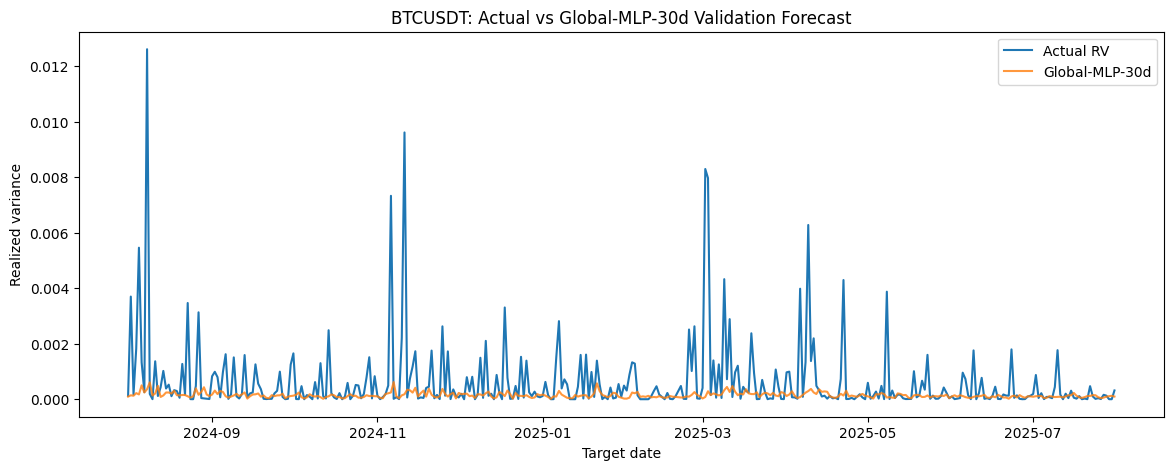

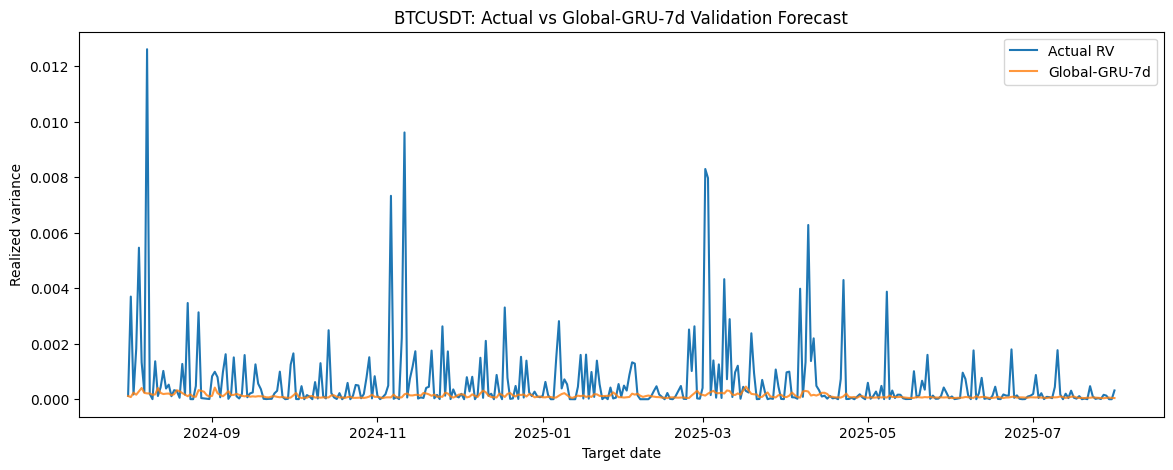

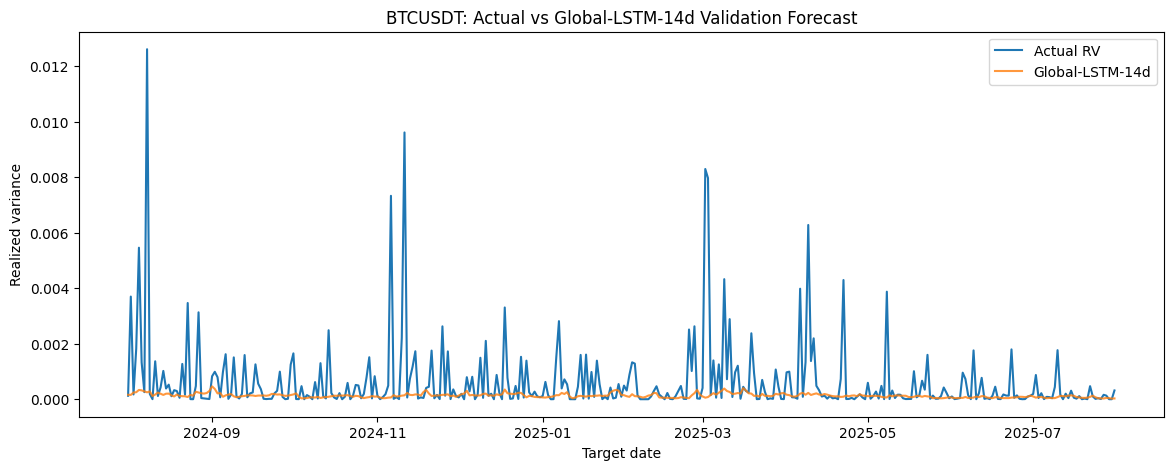

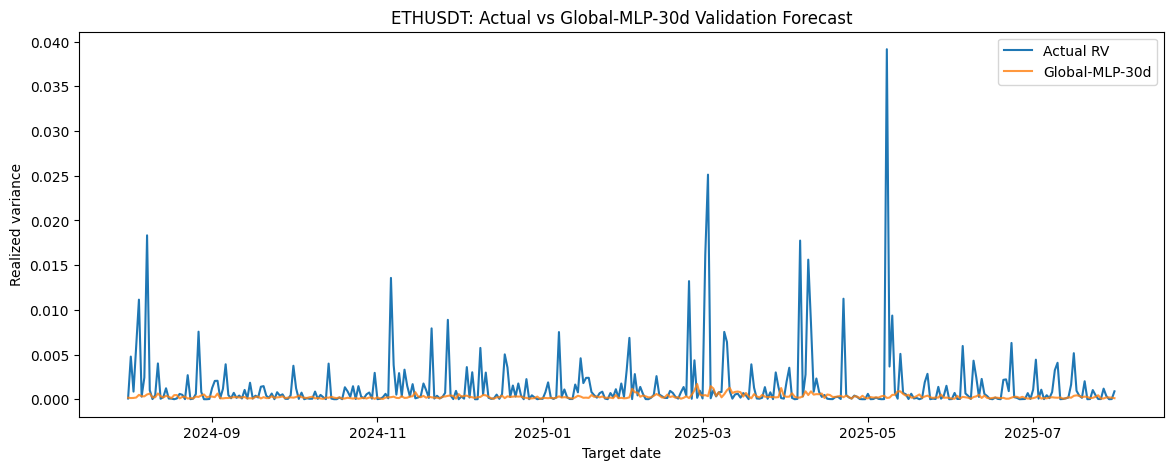

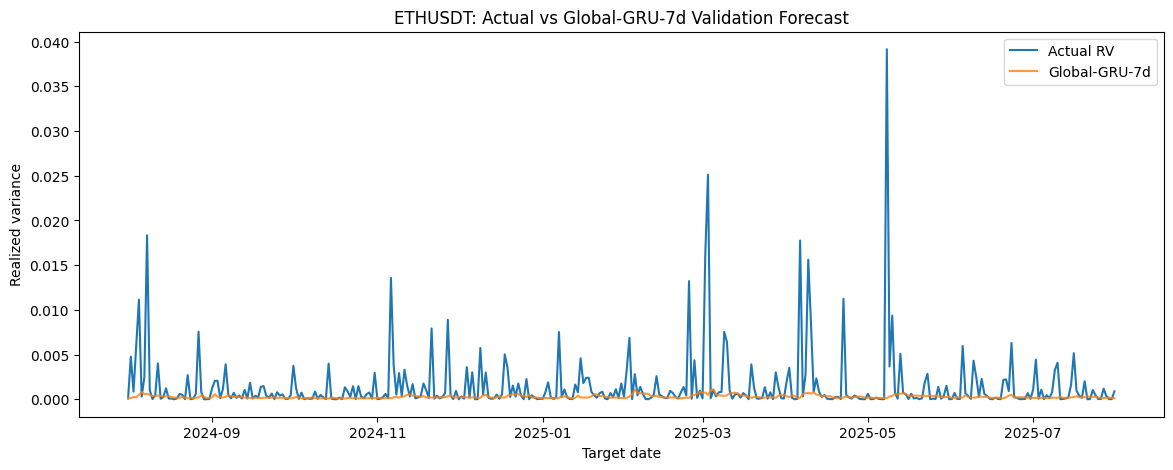

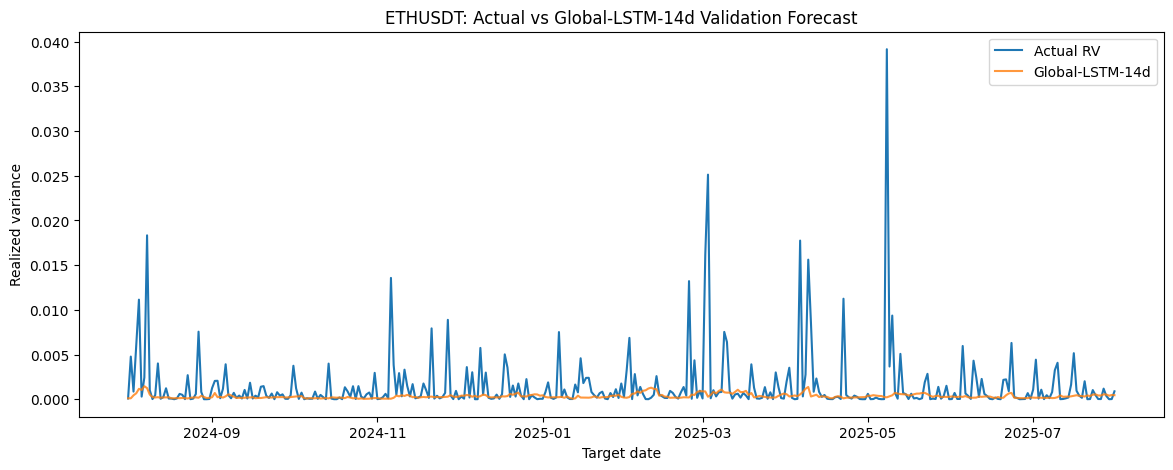

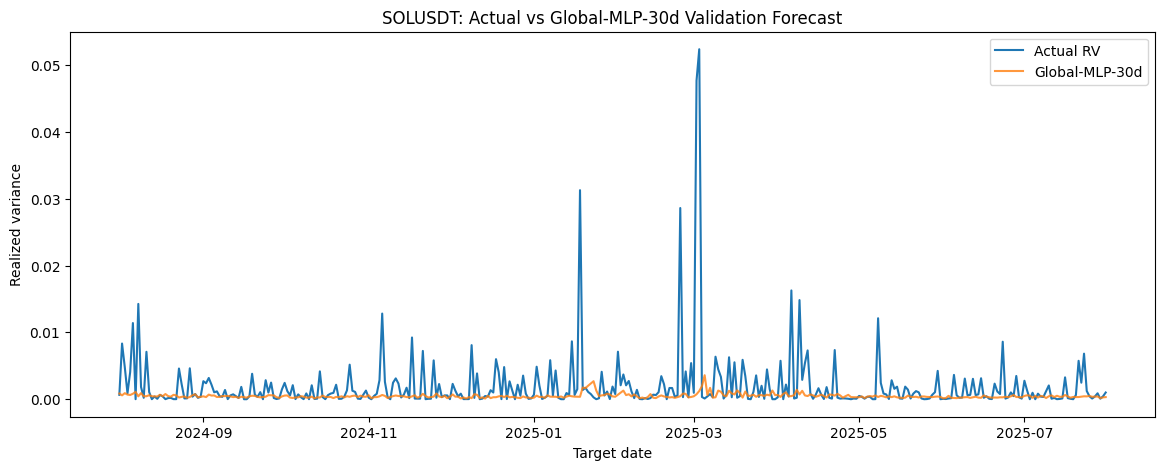

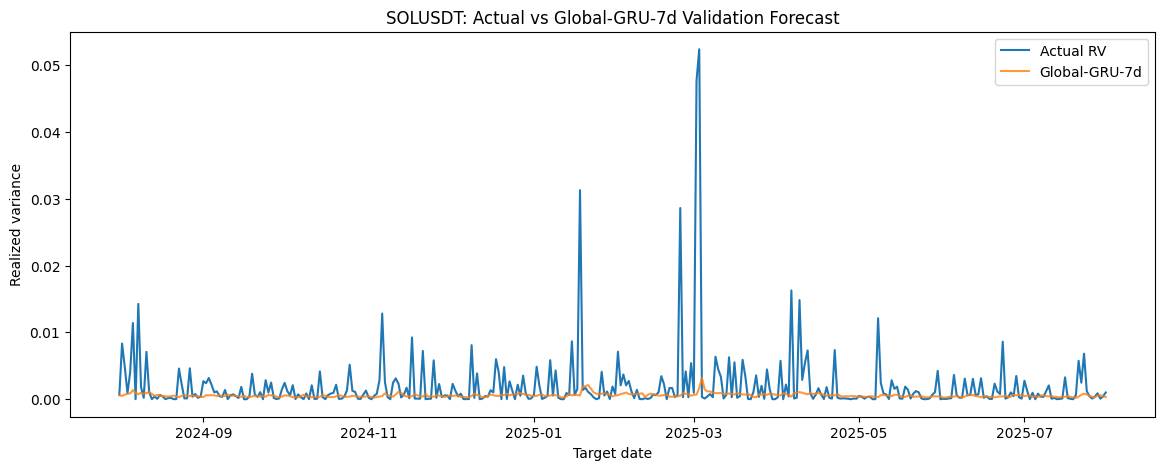

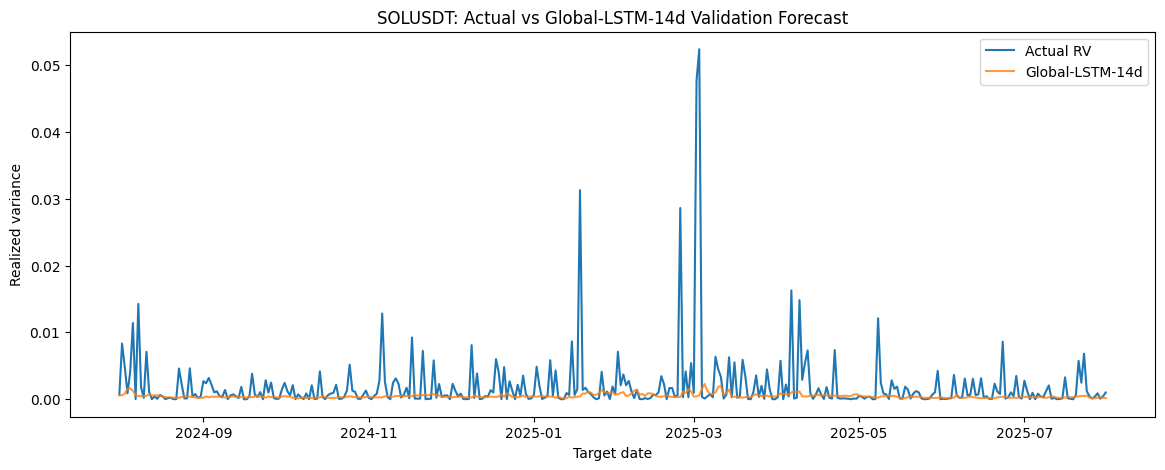

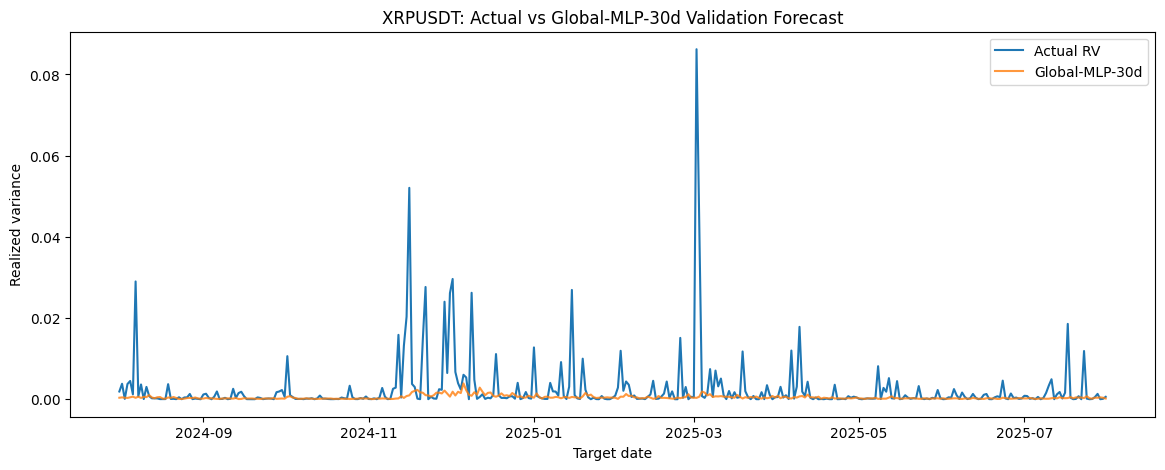

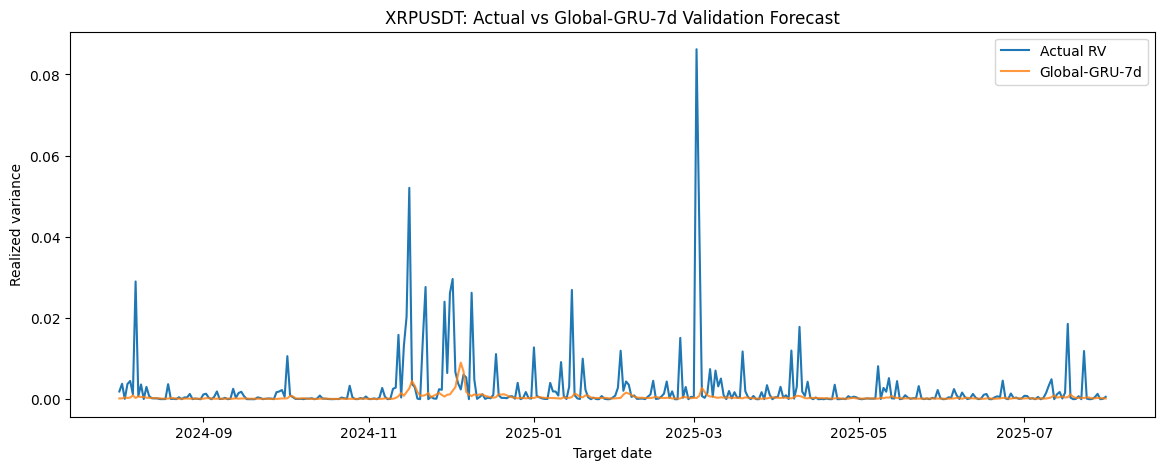

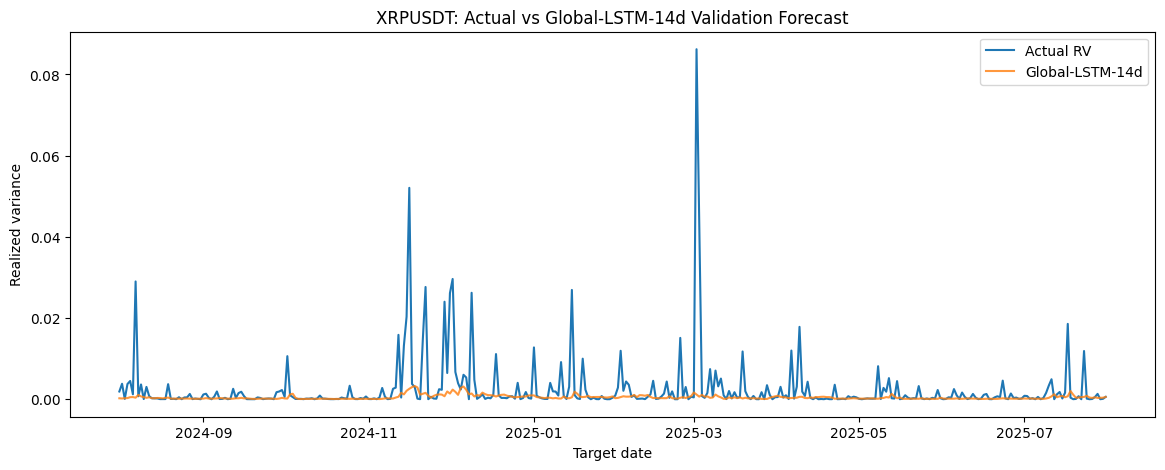

In [14]:
all_predictions_df = pd.concat(
    prediction_frames,
    ignore_index=True,
)

model_names_to_plot = [
    (
        f'Global-{model_name}-'
        f'{MODEL_LOOKBACKS[model_name]}d'
    )
    for model_name
    in MODEL_BUILDERS
]

for symbol in ASSETS:

    for model_name in (
        model_names_to_plot
    ):

        plot_df = (
            all_predictions_df.loc[
                (
                    all_predictions_df[
                        'symbol'
                    ].eq(symbol)
                )
                & (
                    all_predictions_df[
                        'model'
                    ].eq(model_name)
                )
            ]
            .sort_values(
                'target_date'
            )
        )

        if plot_df.empty:
            continue

        plt.figure(
            figsize=(14, 5)
        )

        plt.plot(
            plot_df['target_date'],
            plot_df['actual_rv'],
            label='Actual RV',
        )

        plt.plot(
            plot_df['target_date'],
            plot_df['pred_rv'],
            label=model_name,
            alpha=0.8,
        )

        plt.xlabel(
            'Target date'
        )

        plt.ylabel(
            'Realized variance'
        )

        plt.title(
            f'{symbol}: Actual vs '
            f'{model_name} '
            'Validation Forecast'
        )

        plt.legend()
        plt.show()


## Interpretation

Use asset-level validation QLIKE as the primary metric.

The three global architectures use their previously selected BTC-validation lookbacks:
- Global MLP: 30 days
- Global GRU: 7 days
- Global LSTM: 14 days

This notebook is intended to test whether pooling BTC, ETH, SOL and XRP improves the already-selected single-asset DL specifications. Keep the test period untouched until the final architecture—including any fusion model—is frozen.
